<a href="https://colab.research.google.com/github/Mythili-kirupakaran/Data-visualization-/blob/main/DVT%20WEEK-4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving E Commerce.csv to E Commerce (1).csv
  order_id customer_id  age product_id   country signup_date  \
0  ORD5000    CUST1000   39    PROD200    Canada  01-07-2021   
1  ORD5001    CUST1001   61    PROD201       USA  10/19/2020   
2  ORD5002    CUST1002   26    PROD202  Pakistan  06-10-2023   
3  ORD5003    CUST1003   54    PROD203     India   7/30/2023   
4  ORD5004    CUST1004   50    PROD204     India  12-09-2020   

  last_purchase_date  cancellations_count subscription_status  order_date  \
0          2/21/2023                    0              active   8/20/2024   
1         12-08-2021                    0              active   7/17/2025   
2         09-04-2023                    3           cancelled  03-12-2025   
3          2/20/2024                    4              paused   9/19/2024   
4          9/14/2024                    0              active  08-08-2024   

   unit_price  quantity  purchase_frequency preferred_category  product_name  \
0       78.21         5     

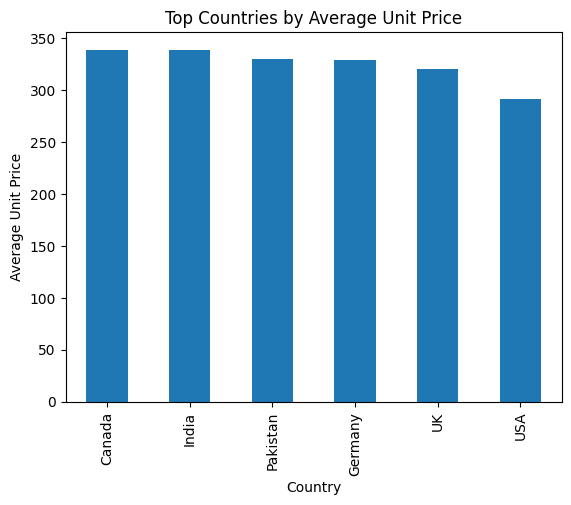


Correlation Matrix
                          age  cancellations_count  unit_price  quantity  \
age                  1.000000             0.006988   -0.030912  0.041570   
cancellations_count  0.006988             1.000000    0.004567  0.004650   
unit_price          -0.030912             0.004567    1.000000 -0.628622   
quantity             0.041570             0.004650   -0.628622  1.000000   
purchase_frequency   0.009055            -0.014788   -0.005085  0.012767   

                     purchase_frequency  
age                            0.009055  
cancellations_count           -0.014788  
unit_price                    -0.005085  
quantity                       0.012767  
purchase_frequency             1.000000  

Correlation between Quantity and Unit Price: -0.6286215861728947


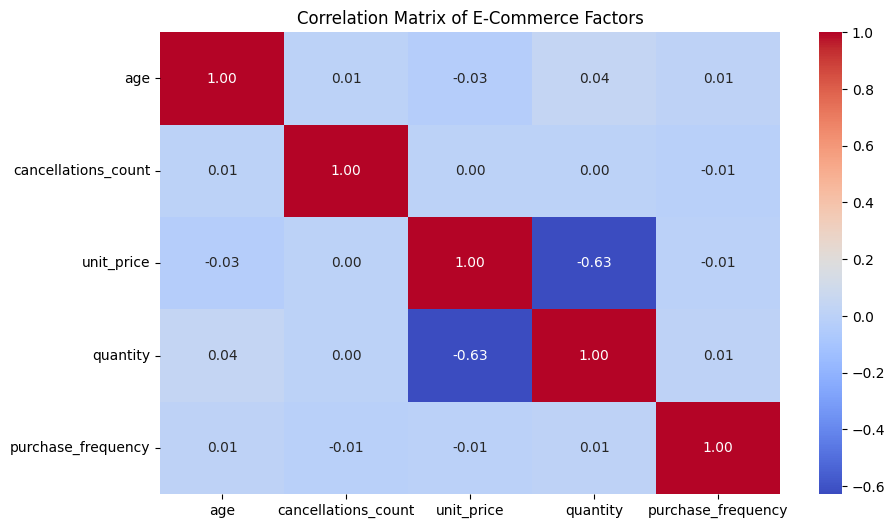

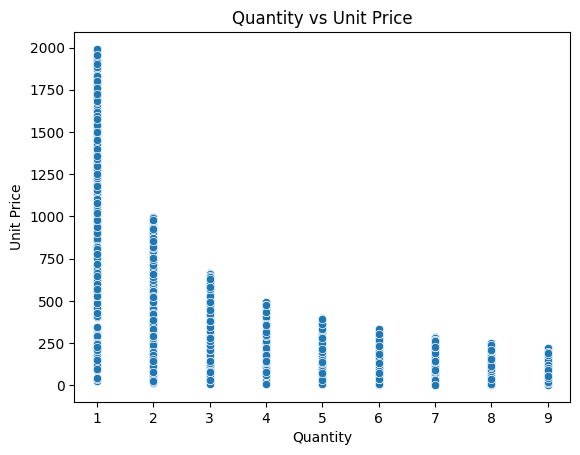

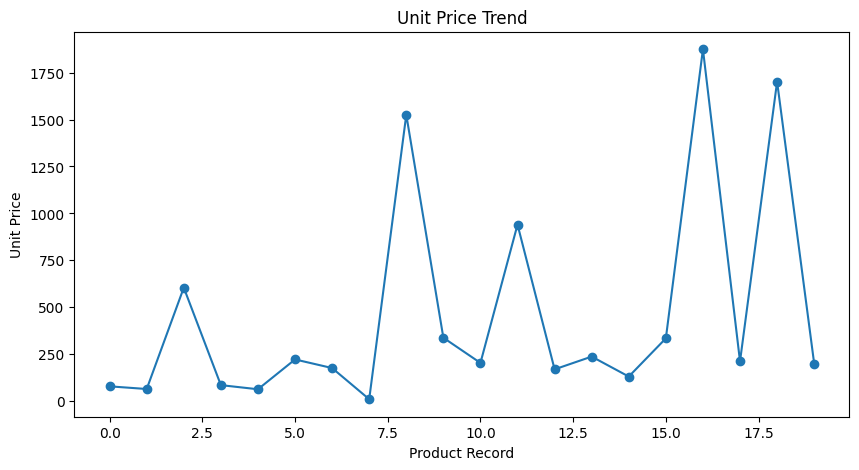

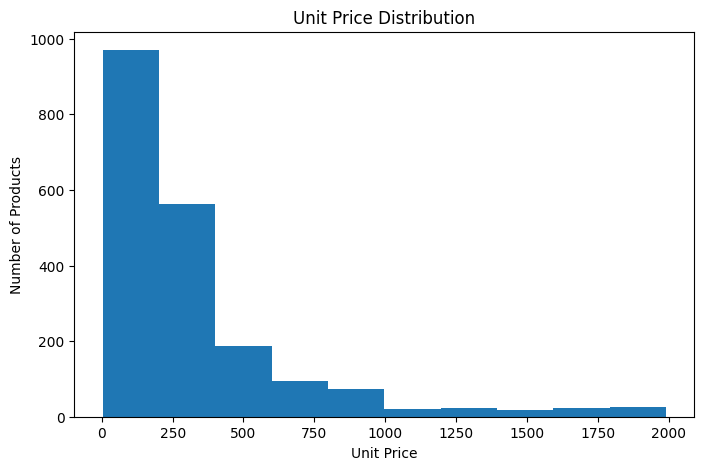

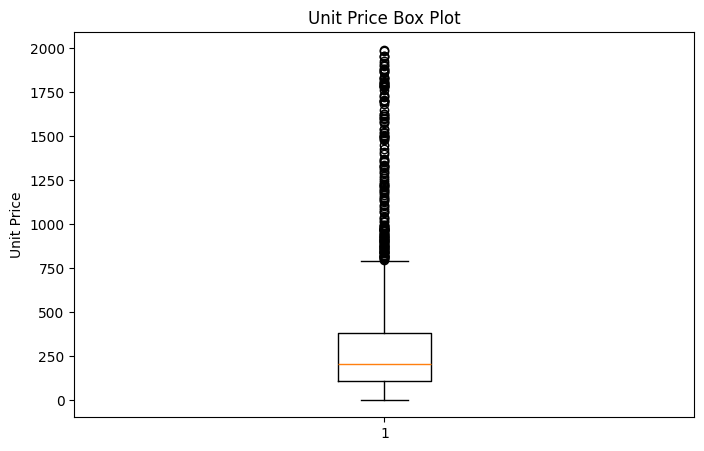

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nData Types")
print(df.dtypes)

print("\nStatistical Summary")
print(df.describe())

high_price = df[df["unit_price"] > 500]

print("\nHigh Unit Price Products")
print(high_price.head())

india = df[df["country"] == "India"]

print("\nCustomers from India")
print(india.head())

sorted_df = df.sort_values(
    by="unit_price",
    ascending=False
)

print("\nTop Products by Unit Price")
print(sorted_df.head())

print("\nMean:", df["unit_price"].mean())

print("Median:", df["unit_price"].median())

print("Mode:")
print(df["unit_price"].mode())

print(
    "Standard Deviation:",
    df["unit_price"].std()
)

country_avg = (
    df.groupby("country")["unit_price"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print("\nAverage Unit Price by Country")
print(country_avg)

country_avg.sort_values(
    ascending=False
).plot(kind="bar")

plt.title("Top Countries by Average Unit Price")
plt.xlabel("Country")
plt.ylabel("Average Unit Price")

plt.show()

corr = df[
    [
        "age",
        "cancellations_count",
        "unit_price",
        "quantity",
        "purchase_frequency"
    ]
].corr()

print("\nCorrelation Matrix")
print(corr)

print(
    "\nCorrelation between Quantity and Unit Price:",
    df["quantity"].corr(df["unit_price"])
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of E-Commerce Factors")

plt.show()

sns.scatterplot(
    data=df,
    x="quantity",
    y="unit_price"
)

plt.title("Quantity vs Unit Price")
plt.xlabel("Quantity")
plt.ylabel("Unit Price")

plt.show()

plt.figure(figsize=(10, 5))

plt.plot(
    df.index[:20],
    df["unit_price"].head(20),
    marker="o"
)

plt.title("Unit Price Trend")
plt.xlabel("Product Record")
plt.ylabel("Unit Price")

plt.show()

plt.figure(figsize=(8, 5))

plt.hist(
    df["unit_price"],
    bins=10
)

plt.title("Unit Price Distribution")
plt.xlabel("Unit Price")
plt.ylabel("Number of Products")

plt.show()

plt.figure(figsize=(8, 5))

plt.boxplot(df["unit_price"])

plt.title("Unit Price Box Plot")
plt.ylabel("Unit Price")

plt.show()

In [ ]:
import pandas as pd
import sqlite3
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("E Commerce.csv")

print("First 5 records:")
print(df.head())

print("\nLast 5 records:")
print(df.tail())

print("\nDataset information:")
df.info()

print("\nDataset shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nStatistical summary:")
print(df.describe(include="all"))

print("\nMissing values:")
print(df.isnull().sum())

df.to_csv("e_commerce_data.csv", index=False)

df.to_excel("e_commerce_data.xlsx", index=False)

conn = sqlite3.connect("e_commerce.db")

df.to_sql("e_commerce", conn, if_exists="replace", index=False)

conn.close()

print("\nCSV, Excel and SQLite files created successfully.")